In [25]:
from utils.analyse_results import GraphsTraining, Results, load_all_pickles, plot_time_bands

train_info = GraphsTraining()

## pyomo

In [26]:
pyomo_2_df = Results.flatten_convergence_data(load_all_pickles("results/study_vdp_2/pyomo_vdp_32_280226"), key_list=["system", "pretrain", "max_t"], model_type="pyomo")

Loaded results/study_vdp_2/pyomo_vdp_32_280226/1072619498_2026-02-28_19-53.pkl
Loaded results/study_vdp_2/pyomo_vdp_32_280226/1306928770_2026-02-28_19-31.pkl
Loaded results/study_vdp_2/pyomo_vdp_32_280226/1488436570_2026-02-28_18-30.pkl
Loaded results/study_vdp_2/pyomo_vdp_32_280226/178209601_2026-02-28_18-27.pkl
Loaded results/study_vdp_2/pyomo_vdp_32_280226/1882170167_2026-02-28_19-38.pkl
Loaded results/study_vdp_2/pyomo_vdp_32_280226/2164459268_2026-02-28_18-28.pkl
Loaded results/study_vdp_2/pyomo_vdp_32_280226/2209311163_2026-02-28_19-42.pkl
Loaded results/study_vdp_2/pyomo_vdp_32_280226/2387134597_2026-02-28_19-32.pkl
Loaded results/study_vdp_2/pyomo_vdp_32_280226/2552832175_2026-02-28_19-33.pkl
Loaded results/study_vdp_2/pyomo_vdp_32_280226/259680134_2026-02-28_19-46.pkl
Loaded results/study_vdp_2/pyomo_vdp_32_280226/2699192998_2026-02-28_19-55.pkl
Loaded results/study_vdp_2/pyomo_vdp_32_280226/2752774435_2026-02-28_18-28.pkl
Loaded results/study_vdp_2/pyomo_vdp_32_280226/2754821

## pytorch

In [27]:
results = load_all_pickles("results/study_vdp_3_1/pytorch_vdp_1000_280226", recursive=False)
pytoch_results_df_3_no_pretrain = Results.flatten_convergence_data(results, model_type="pytorch")


Loaded 0 files from results/study_vdp_3_1/pytorch_vdp_1000_280226


ValueError: No objects to concatenate

### jax

In [28]:
results = load_all_pickles("results/study_vdp_2/jax_vdp_w2-32-2_no_pretrain", recursive=False)
jax_vdp_3_w64_no_pre = Results.flatten_convergence_data(results, model_type="pytorch")

Loaded results/study_vdp_2/jax_vdp_w2-32-2_no_pretrain/2678968404_2026-03-01_00-14.pkl
Loaded results/study_vdp_2/jax_vdp_w2-32-2_no_pretrain/2893899527_2026-03-01_00-05.pkl
Loaded results/study_vdp_2/jax_vdp_w2-32-2_no_pretrain/379768506_2026-03-01_00-20.pkl

Loaded 3 files from results/study_vdp_2/jax_vdp_w2-32-2_no_pretrain


In [29]:
results = load_all_pickles("results/jax_pretrain_pyomo_vdp_w2-64-2/jax_vdp_5000_311225", recursive=False)


Loaded 0 files from results/jax_pretrain_pyomo_vdp_w2-64-2/jax_vdp_5000_311225


In [30]:
pyomo_2_df["pretrain"] = False

comparison_dfs_no_pretrain = {
    # "pyomo_w32": results_df_32,
    "Pyomo": pyomo_2_df,
    #"JAX": jax_vdp_50000_w64,
    "JAX_3": jax_vdp_3_w64_no_pre,
    #"PyTorch": pytoch_results_df_no_pretrain_64,
}

comparison_dfs = {
    # "pyomo_w32": results_df_32,
    "Pyomo": pyomo_2_df, #results_df_64,
    # "JAX": jax_vdp_3_w64, #jax_vdp_10000_40000_w64,
    #"PyTorch": pytoch_results_df_3, #pytoch_results_df_400_w64,
    "JAX_3": jax_vdp_3_w64_no_pre,
    #"pytoch_results_df_3_no_pretrain": pytoch_results_df_3_no_pretrain
}

In [31]:
max_q_maps = {
    "Pyomo": 1.0,
    "JAX": 1.0,
    "PyTorch": 1.0,
}

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:980: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


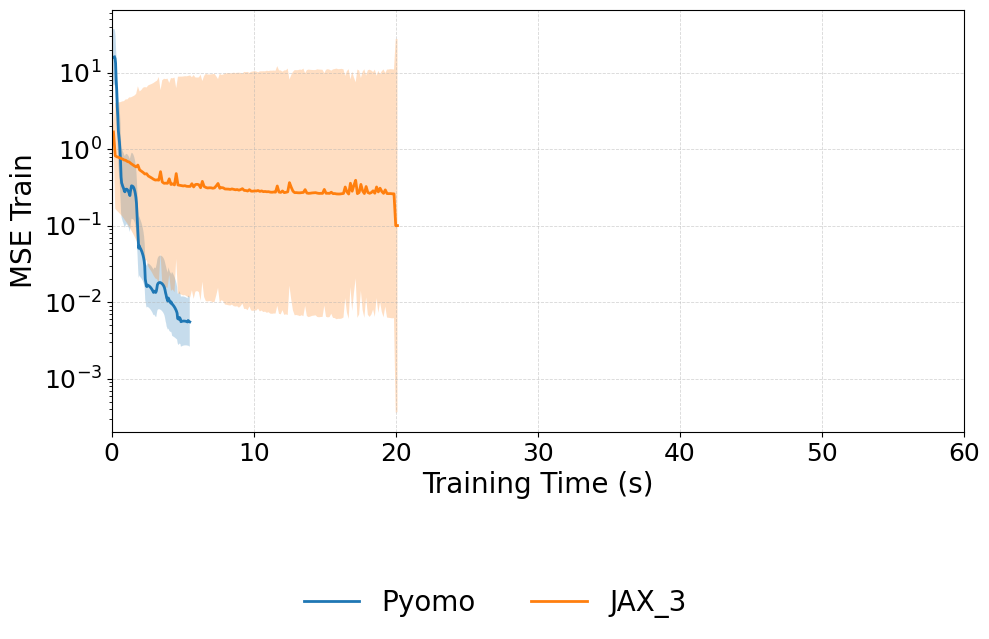

<Axes: xlabel='Training Time (s)', ylabel='MSE Train'>

In [32]:
plot_time_bands(
    comparison_dfs,
    y_col="mse_train",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    figsize=(10, 6),
    label_fontsize=20,
    tick_fontsize=18,
    legend_fontsize=20,
    title_fontsize=16,
    # tmax_quantile=max_q_maps,
    xlim =(0, 60),
    y_label="MSE Train",
    legend_bbox_y=-0.08,
    legend_ncol=2,
    min_support_abs = 1,
)

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:980: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


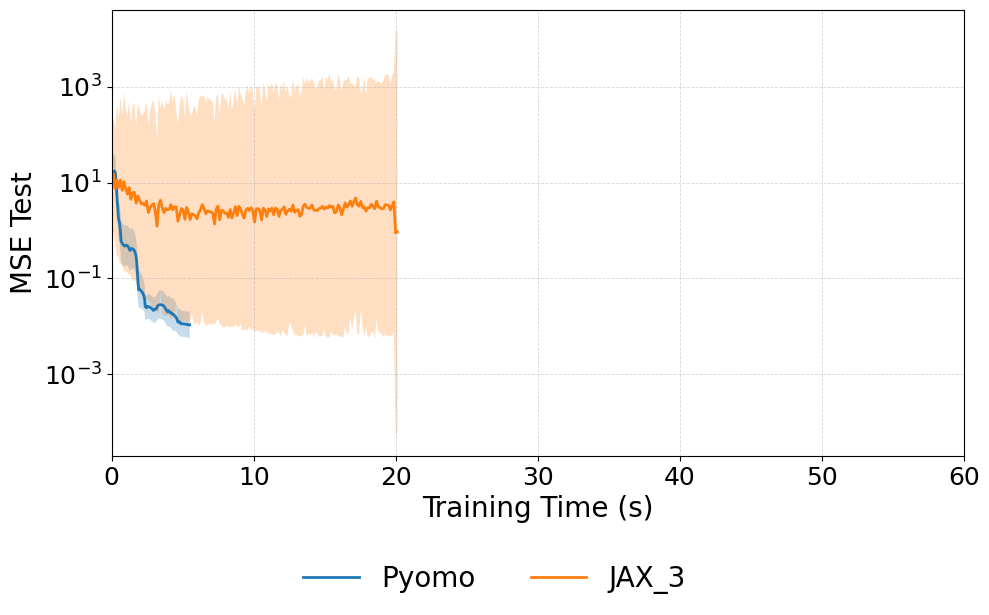

<Axes: xlabel='Training Time (s)', ylabel='MSE Test'>

In [33]:
plot_time_bands(
    comparison_dfs,
    y_col="mse_test",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    figsize=(10, 6),
    label_fontsize=20,
    tick_fontsize=18,
    legend_fontsize=20,
    title_fontsize=16,
    xlim =(0, 60),
    y_label="MSE Test",
    legend_bbox_y=-0.04,
    legend_ncol=3,
    min_support_abs = 1
)